In [ ]:
##MACHINE LEARNING ASSIGNMENT

In [1]:
pip install tensorflow

In [3]:
# libraries
import io
import os
from datetime import datetime
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from sklearn import metrics

# Matplotlib configuration
font = { 'family': 'DejaVu Sans', 'weight': 'bold', 'size': 16 }
plt.rc('font', **font)


In [5]:
# set random seed
np.random.seed(seed=42)

In [ ]:
#LOADING THE DATASETS

In [7]:
PATH = "C:/Users/USER/Downloads/data/data_2025/2025/"
train_path = os.path.join(PATH, "train")

parquet_filenames_train = os.listdir(train_path)
print(parquet_filenames_train[:3])
print(f"Number of files in train: {len(parquet_filenames_train):,}")

['part-00000-of-00362.parquet.parquet', 'part-00001-of-00362.parquet.parquet', 'part-00002-of-00362.parquet.parquet']
Number of files in train: 362


In [9]:
parquet_filenames_train[:3]

['part-00000-of-00362.parquet.parquet',
 'part-00001-of-00362.parquet.parquet',
 'part-00002-of-00362.parquet.parquet']

In [11]:
f"Number of files in train: {len(parquet_filenames_train):,}"

'Number of files in train: 362'

In [13]:
test_path = os.path.join(PATH, "test")

parquet_filenames_test = os.listdir(test_path)
print(parquet_filenames_test[:3])
print(f"Number of files in test: {len(parquet_filenames_test):,}")


['part-00000-of-00362.parquet.parquet', 'part-00001-of-00362.parquet.parquet', 'part-00002-of-00362.parquet.parquet']
Number of files in test: 362


In [15]:
parquet_filenames_test[:3]

['part-00000-of-00362.parquet.parquet',
 'part-00001-of-00362.parquet.parquet',
 'part-00002-of-00362.parquet.parquet']

In [17]:
f"Number of files in test: {len(parquet_filenames_test):,}"

'Number of files in test: 362'

In [ ]:
#EXPLORATORY DATA ANALYSIS

In [19]:
import pandas as pd
train_path = os.path.join(PATH, "train")
test_path = os.path.join(PATH, "test")

# Read parquet files
df_train = pd.read_parquet(train_path)
df_test = pd.read_parquet(test_path)

# Preview the data
df_train.head()

,product_id,title,description,tags,type,room,craft_type,recipient,material,occasion,...,shape,pattern,bottom_category_id,bottom_category_text,top_category_id,top_category_text,primary_color_id,primary_color_text,secondary_color_id,secondary_color_text
0,699437355,Children&#39;s circle skirt BLUE GALAXY made o...,The fuxandfriends children&#39;s full circle s...,,physical,,,,,,...,,,426,clothing.girls_clothing.skirts,5,clothing,2,blue,2,blue
1,1323699538,"Cow Birthday Tutu for kids, Farm Theme Bday Ou...",💄This listing is for the TUTU ONLY (double rib...,"birthday outfit,girls birthday shirt,Tutu outf...",physical,,,,,birthday,...,,animal print,426,clothing.girls_clothing.skirts,5,clothing,11,pink,1,black
2,1142910558,"Zebra print tutu, animal print Skirt, World bo...",All tutus are handmade to order with two layer...,"black and white tutu,striped skirt,zebra tutu,...",physical,,,,,,...,,animal print,426,clothing.girls_clothing.skirts,5,clothing,17,white,1,black
3,1320296928,"Lilac Tutu Rainbow Dots // Girl&#39;s Tutu, Tu...",Step aside because the princess pop star is he...,"tutu,girls skirt,sparkling tutu,fun skirt,ball...",physical,,,,,birthday,...,,,426,clothing.girls_clothing.skirts,5,clothing,12,purple,13,rainbow
4,854901795,Bumblebee tutu yellow and black tutu halloween...,"Sparkle, shimmer, twirl and spin,\nThis tutu&#...","dog tutu,fluffy tutu,dance tutu,skirt,flower g...",physical,,,,,birthday,...,,,426,clothing.girls_clothing.skirts,5,clothing,18,yellow,1,black


In [ ]:
#TRAINING DATASET

In [26]:
f"Number of rows in train: {len(df_train):,}"

'Number of rows in train: 229,624'

In [28]:
f"Number of unique products in train: {len(df_train['product_id'].unique()):,}"

'Number of unique products in train: 229,624'

In [30]:
f"Number of columns in train: {len(df_train.columns):,}"

'Number of columns in train: 23'

In [32]:
list(df_train.columns)

['product_id',
 'title',
 'description',
 'tags',
 'type',
 'room',
 'craft_type',
 'recipient',
 'material',
 'occasion',
 'holiday',
 'art_subject',
 'style',
 'shape',
 'pattern',
 'bottom_category_id',
 'bottom_category_text',
 'top_category_id',
 'top_category_text',
 'primary_color_id',
 'primary_color_text',
 'secondary_color_id',
 'secondary_color_text']

In [34]:
df_train.iloc[0]

product_id                                                      699437355
title                   Children&#39;s circle skirt BLUE GALAXY made o...
description             The fuxandfriends children&#39;s full circle s...
tags                                                                     
type                                                             physical
room                                                                     
craft_type                                                               
recipient                                                                
material                                                                 
occasion                                                                 
holiday                                                                  
art_subject                                                              
style                                                                    
shape                                 

In [36]:
df_train.head(2)

,product_id,title,description,tags,type,room,craft_type,recipient,material,occasion,...,shape,pattern,bottom_category_id,bottom_category_text,top_category_id,top_category_text,primary_color_id,primary_color_text,secondary_color_id,secondary_color_text
0,699437355,Children&#39;s circle skirt BLUE GALAXY made o...,The fuxandfriends children&#39;s full circle s...,,physical,,,,,,...,,,426,clothing.girls_clothing.skirts,5,clothing,2,blue,2,blue
1,1323699538,"Cow Birthday Tutu for kids, Farm Theme Bday Ou...",💄This listing is for the TUTU ONLY (double rib...,"birthday outfit,girls birthday shirt,Tutu outf...",physical,,,,,birthday,...,,animal print,426,clothing.girls_clothing.skirts,5,clothing,11,pink,1,black


In [38]:
df_train['type'].unique()

array(['physical', 'download', ''], dtype=object)

In [40]:
df_train['type'].value_counts(dropna=False)

type
physical    218568
download     10708
               348
Name: count, dtype: int64

In [42]:
f"Number of top categories in train: {len(df_train['top_category_text'].unique()):,}"

'Number of top categories in train: 15'

In [44]:
pd.value_counts(df_train['top_category_text'], sort=True, ascending=False)

C:\Users\USER\AppData\Local\Temp\ipykernel_14824\1076920215.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df_train['top_category_text'], sort=True, ascending=False)


top_category_text
home_and_living                54600
craft_supplies_and_tools       33393
clothing                       30143
toys_and_games                 13835
accessories                    12416
paper_and_party_supplies       12207
bath_and_beauty                11327
weddings                       10143
shoes                           8892
art_and_collectibles            8716
jewelry                         7822
electronics_and_accessories     7474
bags_and_purses                 6650
books_movies_and_music          6262
pet_supplies                    5744
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_14824\1474438048.py:8: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(


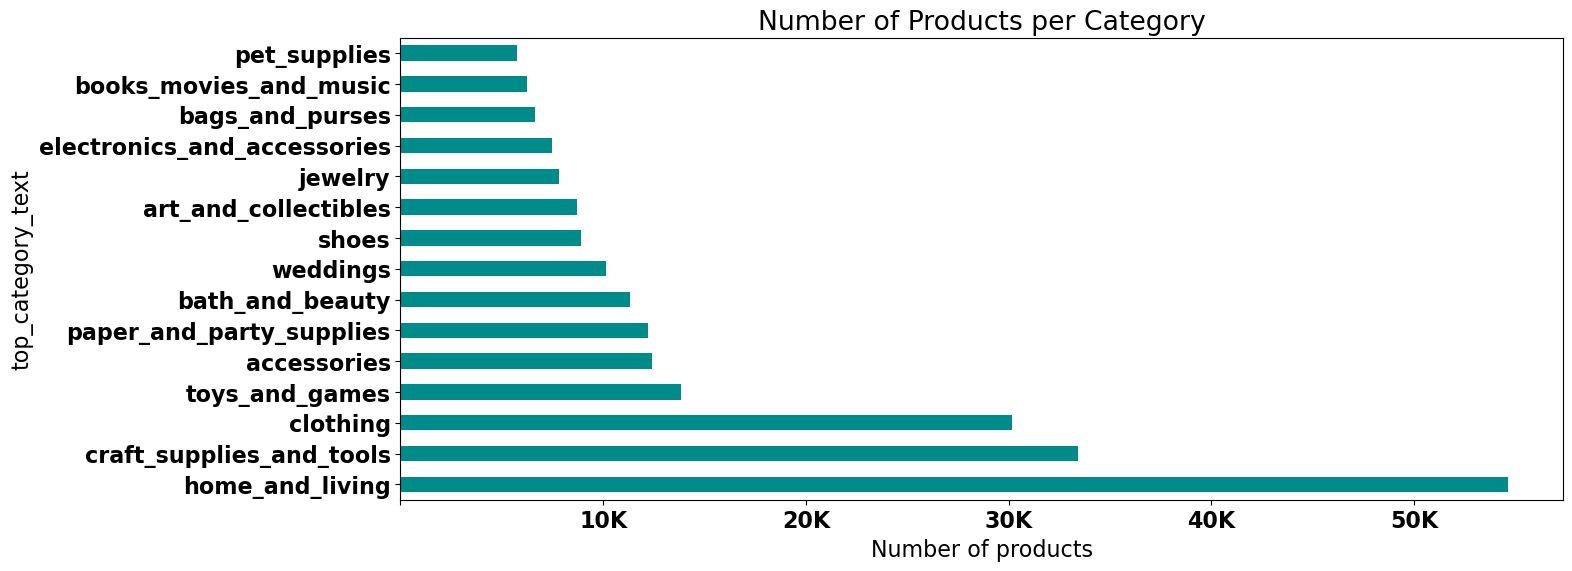

In [46]:
figsize = (15, 6)
column = 'top_category_text'
x_limit = 60000
x_step = 10000
color = 'darkcyan'

figure, ax = plt.subplots(figsize=figsize)
pd.value_counts(
    df_train[column],
    sort=True, ascending=False).plot.barh(color=color)
plt.title(f"Number of Products per Category")
xlabels = [f'{x // 1000:,}K' for x in range(0, x_limit, x_step)]
plt.xticks(range(0, x_limit, x_step), xlabels)
plt.xlabel('Number of products')
plt.setp(ax.get_xticklabels()[0], visible=False)
plt.show()

In [48]:
f"Number of bottom categories in train: {len(df_train['bottom_category_text'].unique()):,}"

'Number of bottom categories in train: 2,609'

In [56]:
 # Compute feature importances
importances = best_clf.feature_importances_
features = X.columns
# Sort the feature importances in descending order
importances_sorted = sorted(zip(features, importances), key=lambda x: x[1], reverse)
features_sorted = [f[0] for f in importances_sorted]
importances_sorted = [f[1] for f in importances_sorted]
# Define colors for the bars
colors = plt.cm.Paired(np.arange(len(importances)))
# Plot the feature importances
plt.figure(figsize=(8, 6))
plt.barh(features_sorted, importances_sorted, color=colors)
plt.xticks(rotation=0)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Classifier Feature Importances')
# Add the feature importance values to the bars
for i, v in enumerate(importances_sorted):
    plt.text(v, i, '{:.2f}'.format(v), color='black', fontsize=10, ha='left', va='c')
plt.show()

SyntaxError: positional argument follows keyword argument (3046506639.py, line 5)

In [ ]:
#TESTING DATASET

In [58]:
f'Number of rows in test: {len(df_test):,}'

f"Number of unique products in test: {len(df_test['product_id'].unique()):,}"

f"Number of columns in test: {len(df_test.columns):,}"

list(df_test.columns)

df_test.iloc[0]

product_id                                             661373440
title          Classroom Valentine Favors, Valentine Pencils,...
description    Valentine Favors, Robots of Love Vinyl Pencil ...
tags           Valentines day favor,kindergarten treats,valen...
type                                                    physical
room                                                            
craft_type                                          kids' crafts
recipient                                                       
material                                                        
occasion                                                        
holiday                                          valentine's day
art_subject                                                     
style                                                           
shape                                                           
pattern                                                         
Name: 0, dtype: object

In [61]:
##PREPROCESSING
!pip install nltk


In [60]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...


True

In [62]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isnull(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs, HTML, emojis, punctuation
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)  # remove digits
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace

    # Tokenize
    tokens = tokenizer.tokenize(text)


    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)


In [71]:
df_train['title_clean'] = df_train['title'].apply(clean_text)
df_train['description_clean'] = df_train['description'].apply(clean_text)
df_train['tags_clean'] = df_train['tags'].apply(clean_text)


In [73]:
# Function to remove emojis
def remove_emojis(text):
    return re.sub(r'[^\w\s,]', '', text)

# Apply the function to the cleaned columns
df_train['title_clean'] = df_train['title_clean'].apply(remove_emojis)
df_train['description_clean'] = df_train['description_clean'].apply(remove_emojis)
df_train['tags_clean'] = df_train['tags_clean'].apply(remove_emojis)

# You can check the result:
print(df_train[['title_clean', 'description_clean', 'tags_clean']].head())

                                         title_clean  \
0  childrens circle skirt blue galaxy made light ...   
1  cow birthday tutu kid farm theme bday outfit p...   
2  zebra print tutu animal print skirt world book...   
3  lilac tutu rainbow dot girl tutu tulle skirt d...   
4  bumblebee tutu yellow black tutu halloween tut...   

                                   description_clean  \
0  fuxandfriends childrens full circle skirt exhi...   
1  listing tutu double ribbion include shirtany p...   
2  tutu handmade order two layer tulle strip fabr...   
3  step aside princess pop star win heart made hi...   
4  sparkle shimmer twirl spinnthis tutu fun begin...   

                                          tags_clean  
0                                                     
1  birthday outfitgirls birthday shirttutu outfit...  
2  black white tutustriped skirtzebra tutusafaris...  
3  tutugirls skirtsparkling tutufun skirtballet t...  
4  dog tutufluffy tutudance tutuskirtflower girl ..

In [69]:
df_train['combined_text'] = df_train['title_clean'] + ' ' + df_train['description_clean'] + ' ' + df_train['tags_clean']


## Model Training

Let's first split the data to be able to evaluate our model against a validation dataset. This validation set can also be used to fine tune your model before making the predictions on the hidden test set.

In [71]:
from sklearn.model_selection import train_test_split

df_training, df_validation = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train['bottom_category_text'],
    random_state=42)

In [73]:
f"Number of products for training: {len(df_training):,}"

'Number of products for training: 206,661'

In [75]:
f"Number of products for validation: {len(df_validation):,}"

'Number of products for validation: 22,963'

In [77]:
df_training['bottom_category_text'].value_counts()

bottom_category_text
jewelry.earrings.dangle_earrings.chandbalis                                         88
accessories.scarves_and_wraps.scarves                                               88
home_and_living.kitchen_and_dining.dining_and_serving.cake_stands                   88
craft_supplies_and_tools.closures_and_fasteners.buttons                             88
art_and_collectibles.drawing_and_illustration.architectural_drawings                88
                                                                                    ..
weddings.clothing.jumpsuits_and_rompers                                             40
clothing.girls_clothing.baby_girls_clothing.socks_and_leg_warmers                   40
home_and_living.lighting.light_accessories                                          39
clothing.womens_clothing.pajamas_and_robes.sleep_masks_and_blindfolds.blindfolds    38
craft_supplies_and_tools.doll_and_model_supplies.noise_makers                       38
Name: count, Length: 2

In [79]:
df_validation['bottom_category_text'].value_counts()

bottom_category_text
clothing.girls_clothing.underwear.panties                                                                             10
craft_supplies_and_tools.paints_inks_and_dyes.paint.chalk_paint                                                       10
clothing.girls_clothing.baby_girls_clothing.sweaters                                                                  10
craft_supplies_and_tools.storage_and_organization.containers.bottles_cans_and_jars.lids_rings_and_caps.bottle_caps    10
paper_and_party_supplies.party_supplies.party_decor.party_candles                                                     10
                                                                                                                      ..
home_and_living.furniture.entryway_furniture.standing_coat_racks                                                       4
jewelry.earrings.kaan_chains                                                                                           4
craft_suppl

In [81]:
df_training['top_category_text'].value_counts()

top_category_text
home_and_living                49140
craft_supplies_and_tools       30056
clothing                       27139
toys_and_games                 12448
accessories                    11173
paper_and_party_supplies       10984
bath_and_beauty                10187
weddings                        9128
shoes                           8001
art_and_collectibles            7846
jewelry                         7040
electronics_and_accessories     6727
bags_and_purses                 5986
books_movies_and_music          5636
pet_supplies                    5170
Name: count, dtype: int64

In [83]:
df_validation['top_category_text'].value_counts()

top_category_text
home_and_living                5460
craft_supplies_and_tools       3337
clothing                       3004
toys_and_games                 1387
accessories                    1243
paper_and_party_supplies       1223
bath_and_beauty                1140
weddings                       1015
shoes                           891
art_and_collectibles            870
jewelry                         782
electronics_and_accessories     747
bags_and_purses                 664
books_movies_and_music          626
pet_supplies                    574
Name: count, dtype: int64

In [85]:
#TOP CATEGORY-TRAINING USING LOGISTIC REGRESSION

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from scipy.sparse import hstack

# 1. Combine the text columns
df_train['combined_text'] = df_train['title_clean'].fillna('') + ' ' + \
                            df_train['description_clean'].fillna('') + ' ' + \
                            df_train['tags_clean'].fillna('')

df_validation['combined_text'] = df_validation['title_clean'].fillna('') + ' ' + \
                                 df_validation['description_clean'].fillna('') + ' ' + \
                                 df_validation['tags_clean'].fillna('')

# 2. TF-IDF vectorization for combined text
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_tfidf = vectorizer.fit_transform(df_train['combined_text'])
X_val_tfidf = vectorizer.transform(df_validation['combined_text'])

# 3. One-hot encode 'material'
df_train['material'] = df_train['material'].fillna('missing')
df_validation['material'] = df_validation['material'].fillna('missing')

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_material = encoder.fit_transform(df_train[['material']])
X_val_material = encoder.transform(df_validation[['material']])

# 4. Combine features
X_train = hstack([X_train_tfidf, X_train_material])
X_val = hstack([X_val_tfidf, X_val_material])

# 5. Labels
y_train = df_train['top_category_text'].values
y_val = df_validation['top_category_text'].values

# 6. Train Logistic Regression
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

# 7. Predict and evaluate
y_pred = clf.predict(X_val)

f1 = f1_score(y_val, y_pred, average='weighted')
print(f"F1 score: {f1:.4f}")
print(classification_report(y_val, y_pred))

# 8. Show one example
index = 0
print(f"""
Product's title: {df_validation['title'].iloc[index][:80]}...
Prediction: '{y_pred[index]}', Groundtruth: '{y_val[index]}'
""".strip())


F1 score: 0.8619
                             precision    recall  f1-score   support

                accessories       0.80      0.86      0.83      1243
       art_and_collectibles       0.62      0.83      0.71       870
            bags_and_purses       0.79      0.92      0.85       664
            bath_and_beauty       0.84      0.91      0.87      1140
     books_movies_and_music       0.80      0.94      0.87       626
                   clothing       0.97      0.94      0.95      3004
   craft_supplies_and_tools       0.87      0.78      0.83      3337
electronics_and_accessories       0.84      0.95      0.89       747
            home_and_living       0.94      0.82      0.88      5460
                    jewelry       0.84      0.95      0.89       782
   paper_and_party_supplies       0.80      0.89      0.84      1223
               pet_supplies       0.88      0.96      0.92       574
                      shoes       0.94      0.98      0.96       891
             toy

In [75]:
#TRAINING-BOTTOM CATEGORY USING LOGISTIC REGRESSION

df_train = pd.read_csv("dataml.csv")
df_train = df_train.loc[:, ~df_train.columns.str.startswith('cat_level_')]
split_cols = df_train['bottom_category_text'].str.split('.', expand=True)
split_cols.columns = [f'cat_level_{i+1}' for i in range(split_cols.shape[1])]
df_train = pd.concat([df_train, split_cols], axis=1)

C:\Users\USER\AppData\Local\Temp\ipykernel_20000\2185016515.py:1: DtypeWarning: Columns (5,6,8,11,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("dataml.csv")


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression




In [81]:
df_train['deepest_cat'] = df_train.apply(
    lambda row: next((row[col] for col in reversed(split_cols.columns) if pd.notnull(row[col])), None), axis=1)

df_training, df_validation = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train['bottom_category_text'],
    random_state=42
)

print(f"Training size: {len(df_training):,}")
print(f"Validation size: {len(df_validation):,}")

Training size: 206,661
Validation size: 22,963


In [83]:
def get_deepest_category(row):
    levels = []
    for col in ['cat_level_1', 'cat_level_2', 'cat_level_3', 'cat_level_4', 'cat_level_5', 'cat_level_6', 'cat_level_7']:
        if pd.notnull(row[col]):
            levels.append(row[col])
    return ' > '.join(levels) if levels else 'unknown'

df_training['deepest_cat'] = df_training.apply(get_deepest_category, axis=1)
df_validation['deepest_cat'] = df_validation.apply(get_deepest_category, axis=1)

In [89]:
coarse_le = LabelEncoder()
df_training['coarse'] = coarse_le.fit_transform(df_training['cat_level_1'])
df_validation['coarse'] = coarse_le.transform(df_validation['cat_level_1'])

In [91]:
# Text data
X_train_text = df_training['combined_text'].values
X_val_text = df_validation['combined_text'].values

In [102]:
print(" Stage 1: Training Coarse Category Classifier...")

pipeline_coarse = Pipeline([
    ('vect', CountVectorizer(max_features=15000, stop_words='english', ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'))
])

pipeline_coarse.fit(X_train_text, df_training['coarse'])
y_coarse_val_pred = pipeline_coarse.predict(X_val_text)

 Stage 1: Training Coarse Category Classifier...


In [106]:
import time


In [110]:
# --- Stage 2: Fine Category Prediction within each Coarse Group ---
print("\n Stage 2: Training Fine Category Classifiers...")

# Prepare results
all_fine_preds = []
all_fine_true = []
all_fine_names = []

all_bottom_category_ids = []

fine_label_decoder = {}
batch_size = 25

for coarse_label in np.unique(df_training['coarse']):
    coarse_name = coarse_le.inverse_transform([coarse_label])[0]
    print(f"\n🔹 Coarse Category: {coarse_name}")

    # Filter for current group
    train_mask = df_training['coarse'] == coarse_label
    val_mask = y_coarse_val_pred == coarse_label
    if train_mask.sum() == 0 or val_mask.sum() == 0:
        print(" Skipping - No data.")
        continue

    X_train_group = X_train_text[train_mask]
    y_train_group = df_training['deepest_cat'][train_mask]
    X_val_group = X_val_text[val_mask]
    y_val_group = df_validation['deepest_cat'][val_mask]

    # Encode fine labels for this group
    fine_le = LabelEncoder()
    y_train_fine = fine_le.fit_transform(y_train_group)

    # Save mapping for later decoding
    for i, label in enumerate(fine_le.classes_):
        fine_label_decoder[(coarse_label, i)] = label

    # Filter val examples to only those with known fine classes
    val_known_mask = y_val_group.isin(fine_le.classes_)
    if val_known_mask.sum() == 0:
        print(" Skipping - No known fine classes in validation.")
        continue

    X_val_group = X_val_group[val_known_mask]
    y_val_group = y_val_group[val_known_mask]
    y_val_fine_true = fine_le.transform(y_val_group)

    unique_fine = np.unique(y_train_fine)
    total_batches = int(np.ceil(len(unique_fine) / batch_size))

    for i in range(0, len(unique_fine), batch_size):
        batch_num = i // batch_size + 1
        start_time = time.time()

        batch_classes = unique_fine[i:i + batch_size]
        train_batch_mask = np.isin(y_train_fine, batch_classes)
        val_batch_mask = np.isin(fine_le.transform(y_val_group), batch_classes)

        if train_batch_mask.sum() == 0 or val_batch_mask.sum() == 0:
            print(f"Skipping fine batch {batch_num}/{total_batches} - No data.")
            continue

        X_batch_train = X_train_group[train_batch_mask]
        y_batch_train = y_train_fine[train_batch_mask]
        X_batch_val = X_val_group[val_batch_mask]
        y_batch_val = fine_le.transform(y_val_group[val_batch_mask])

        text_clf_fine = Pipeline([
            ('vect', CountVectorizer(max_features=15000, stop_words='english', ngram_range=(1, 2))),
            ('tfidf', TfidfTransformer(sublinear_tf=True)),
            ('clf', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'))
        ])

        text_clf_fine.fit(X_batch_train, y_batch_train)
        y_pred_batch = text_clf_fine.predict(X_batch_val)

        # Save predicted bottom category IDs
        all_bottom_category_ids.extend(y_pred_batch)

        all_fine_preds.extend(y_pred_batch)
        all_fine_true.extend(y_batch_val)

        for label in y_batch_val:
            all_fine_names.append(fine_label_decoder.get((coarse_label, label), 'unknown'))

        elapsed = time.time() - start_time
        print(f" Finished fine batch {batch_num}/{total_batches} - Took {elapsed:.2f}s")


 Stage 2: Training Fine Category Classifiers...

🔹 Coarse Category: accessories
 Finished fine batch 1/6 - Took 2.45s
 Finished fine batch 2/6 - Took 2.14s
 Finished fine batch 3/6 - Took 2.13s
 Finished fine batch 4/6 - Took 2.12s
 Finished fine batch 5/6 - Took 2.21s
 Finished fine batch 6/6 - Took 1.00s

🔹 Coarse Category: art_and_collectibles
 Finished fine batch 1/4 - Took 1.91s
 Finished fine batch 2/4 - Took 1.93s
 Finished fine batch 3/4 - Took 1.81s
 Finished fine batch 4/4 - Took 2.16s

🔹 Coarse Category: bags_and_purses
 Finished fine batch 1/3 - Took 2.08s
 Finished fine batch 2/3 - Took 2.46s
 Finished fine batch 3/3 - Took 2.19s

🔹 Coarse Category: bath_and_beauty
 Finished fine batch 1/6 - Took 3.09s
 Finished fine batch 2/6 - Took 2.12s
 Finished fine batch 3/6 - Took 2.19s
 Finished fine batch 4/6 - Took 2.61s
 Finished fine batch 5/6 - Took 2.87s
 Finished fine batch 6/6 - Took 0.51s

🔹 Coarse Category: books_movies_and_music
 Finished fine batch 1/3 - Took 2.27s
 Fi

In [118]:
import pandas as pd

y_pred_top = pipeline_coarse.predict(X_val_text)
top_category_ids = coarse_le.inverse_transform(y_pred_top)

# Ensure all lists are the same length
final_size = min(len(df_validation), len(y_pred_top), len(all_fine_names))

# Create the DataFrame
df_final_predictions = pd.DataFrame({
    'product_id': df_validation['product_id'].values[:final_size],
    'top_category_pred': y_pred_top[:final_size],
    'bottom_category_pred': all_fine_names[:final_size],
    'top_category_id': top_category_ids[:final_size],
    'bottom_category_id': all_bottom_category_ids[:final_size]
})

df_final_predictions.to_parquet(f"predictions_15865.parquet")
print(df_final_predictions)

       product_id  top_category_pred  \
0      1085759015                  8   
1      1335195314                 10   
2      1107495477                  6   
3       937877694                  5   
4      1157554433                  8   
...           ...                ...   
19707   805253222                  8   
19708  1036998673                  8   
19709   635944323                  8   
19710   842116719                  6   
19711  1392649524                 13   

                                    bottom_category_pred  \
0         accessories > bouquets_and_corsages > corsages   
1                         accessories > baby_accessories   
2        accessories > costume_accessories > facial_hair   
3      accessories > costume_accessories > costume_ta...   
4      accessories > costume_accessories > costume_go...   
...                                                  ...   
19707  weddings > jewelry > cuff_links_and_tie_tacks ...   
19708      weddings > jewelry > cuff_li

In [120]:
f1_bottom = metrics.f1_score(all_fine_true, all_fine_preds, average='weighted')

In [122]:
f"F1 score: {f1_bottom:.4f}"

'F1 score: 0.8093'

In [107]:
X_train_text = df_training['combined_text'].values
X_val_text = df_validation['combined_text'].values

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.preprocessing import LabelEncoder

In [148]:
train_text = df_training['title'].fillna('').values

In [149]:
train_labels = df_training['top_category_text'].values

In [155]:
val_text = df_validation['title'].fillna('').values
val_labels = df_validation['top_category_text'].values

In [ ]:
df_validation.iloc[0]

product_id                                                     1085759015
title                   Vintage enamel funnel - White metal funnel wit...
description             Vintage enamel funnel - White metal funnel wit...
tags                    Enamel Funnel,Vintage metal funnel,Enamelware ...
type                                                             physical
room                                                                     
craft_type                                                     winemaking
recipient                                                                
material                                                                 
occasion                                                                 
holiday                                                                  
art_subject                                                              
style                                                                    
shape                                 

In [ ]:
val_text[:1]

array(['Vintage enamel funnel - White metal funnel with handle - Large rusty funnel - Kitchen pouring tool - Bulgarian enamelware - Old shabby chic'],
      dtype=object)

## Submission


In [130]:
df_predictions = df_test.copy()

In [150]:
# Build mapping from top category name to ID
top_category_name_to_id = dict(zip(df_training['cat_level_1'], df_training['coarse']))

# Map predicted top categories to IDs
top_category_ids = [top_category_name_to_id.get(name, -1) for name in y_pred_top]

# Assign to the predictions DataFrame
df_predictions["top_category_id"] = top_category_ids


In [142]:
print("Validation samples:", len(df_validation))
print("Predicted top categories:", len(y_pred_top))


Validation samples: 22963
Predicted top categories: 22963


In [144]:
df_predictions = df_validation.copy()


In [146]:
df_predictions["top_category_pred"] = y_pred_top
df_predictions["top_category_id"] = top_category_ids


In [148]:

df_predictions["top_category_id"] = top_category_ids
#df_predictions["bottom_category_id"] = np.zeros(len(df_test), dtype=int)

In [152]:
student_id = "12345689"
df_predictions[
    ["product_id", "top_category_id", "bottom_category_id"]
].to_parquet(f"predictions_{student_id}.parquet")

In [156]:
# Prepare the features for prediction 
X_test = df_predictions['combined_text']  

# Make predictions
y_pred_top = pipeline_coarse.predict(X_test)

# Map the predicted top categories to IDs 
top_category_name_to_id = dict(zip(df_training['cat_level_1'], df_training['coarse']))
top_category_ids = [top_category_name_to_id.get(name, -1) for name in y_pred_top]


In [164]:



 y_pred_bottom = pipeline_coarse.predict(X_test)



# Map bottom category names to their IDs 
bottom_category_name_to_id = dict(zip(df_training['cat_level_2'], df_training['bottom_category_id']))  # Replace with actual mapping
bottom_category_ids = [bottom_category_name_to_id.get(name, -1) for name in y_pred_bottom]

#Submission DataFrame
submission = pd.DataFrame({
    'product_id': df_predictions['product_id'],
    'top_category_pred': y_pred_top,  # Category names predicted by the model
    'top_category_id': top_category_ids,  # Top category IDs based on predicted names
    'bottom_category_id': bottom_category_ids  # Bottom category IDs (you may need to adjust based on your model)
})

# Save Parquet
submission.to_parquet('submission_file.parquet', index=False)

print("Submission file created successfully.")


Submission file created successfully.


In [ ]:
#VISUALISATION

In [172]:
# Extract TF-IDF features (document vectors)
X_embeddings = pipeline_coarse.named_steps['tfidf'].transform(
    pipeline_coarse.named_steps['vect'].transform(df_validation['combined_text'])
)


In [179]:
pip install umap-learn


Note: you may need to restart the kernel to use updated packages.


In [181]:
import matplotlib.pyplot as plt
import umap
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X_embeddings)


C:\Users\USER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


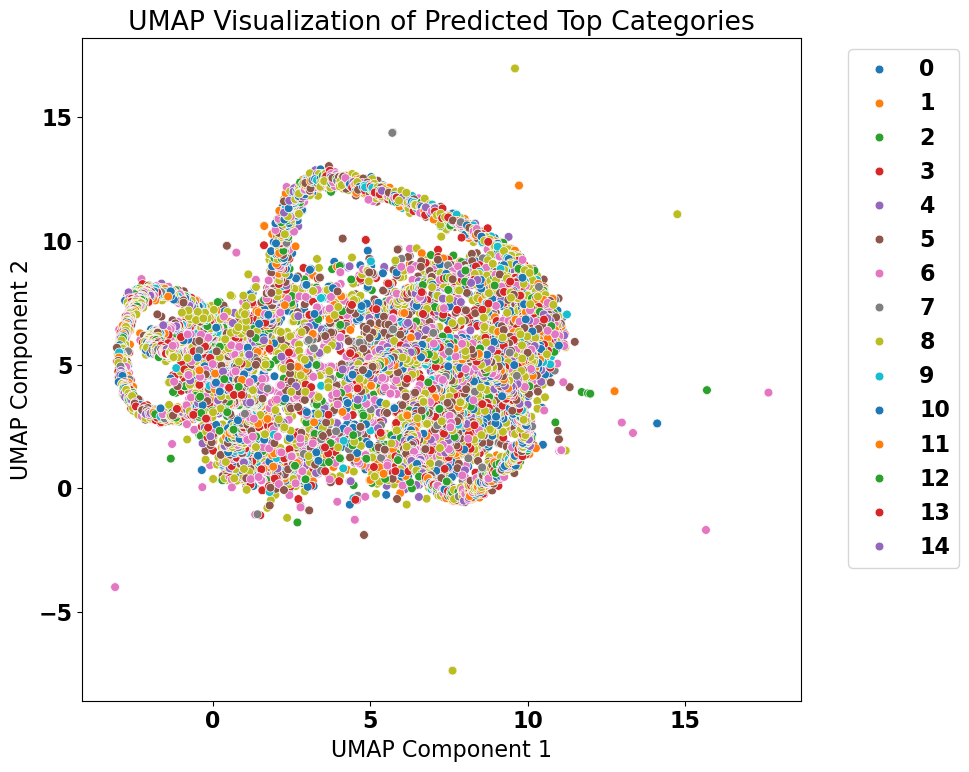

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_2d[:, 0], y=X_2d[:, 1],
    hue=y_pred_top,  
    palette='tab10',
    legend='full',
    s=40
)
plt.title("UMAP Visualization of Predicted Top Categories")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


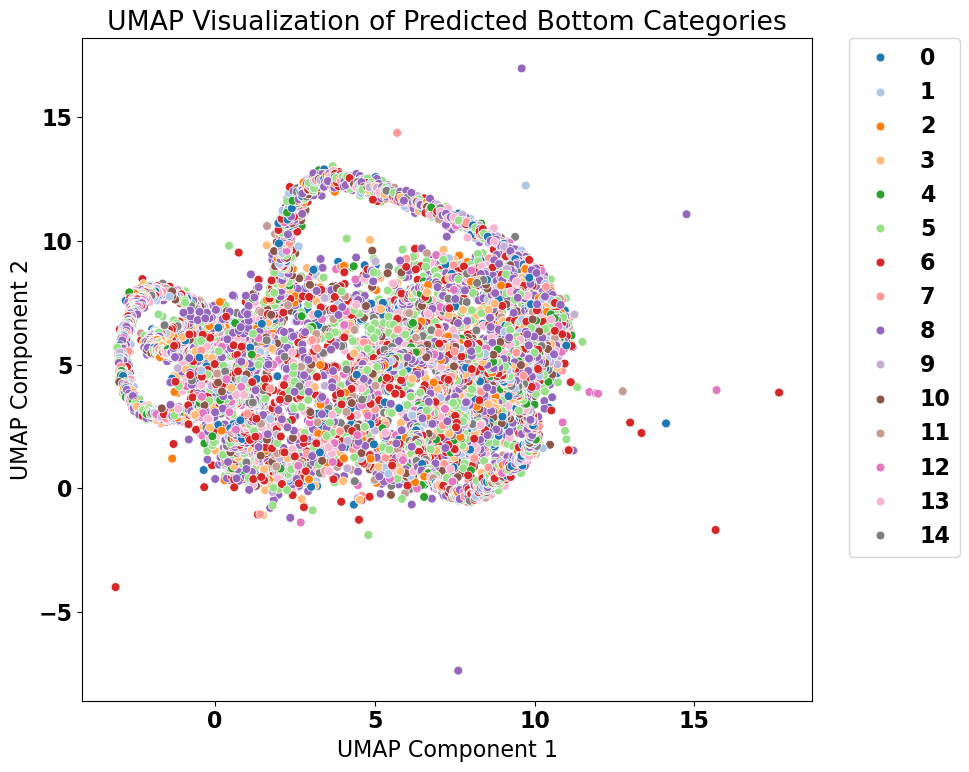

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_2d[:, 0], y=X_2d[:, 1],
    hue=y_pred_bottom,  
    palette='tab20',     
    legend='full',
    s=40
)
plt.title("UMAP Visualization of Predicted Bottom Categories")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()
